# Rice-Paper — a quantitative teardown
### Daily OHLCV · six candlestick patterns · random-day baseline · HAC inference · Bonferroni correction · 15 tickers × 16 years

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random_days%3F: Not--Supported](https://img.shields.io/badge/Beats_random_days%3F-Not--Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether six Japanese candlestick reversal patterns produce excess forward returns (1-day and 5-day) over a random-day baseline with matched direction, across a 15-ticker daily panel, with a Bonferroni correction for 12 simultaneous tests.

> **Not investment advice.** Real data: Yahoo daily bars, 2010-01-04 – 2026-06-12; offline core and tests run on a deterministic synthetic tape. Methods and sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rice_paper import data, strategy as st

TICKERS = [
    "SPY", "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA",
    "JPM", "BAC", "XOM", "JNJ", "PG", "KO", "WMT",
]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost=0.0, seed=76):
    """Pool pattern study results across the basket (cached real tapes)."""
    frames = {name: [] for name in st.PATTERN_NAMES}
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        study = st.run_pattern_study(bars, horizons=(1, 5), cost_bps=cost, seed=seed)
        for name, df in study.items():
            frames[name].append(df)
    return {name: pd.concat(dfs, ignore_index=True) for name, dfs in frames.items() if dfs}

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 12 tests (6 patterns × 2 horizons); highest excess HAC *t* = **2.16** (doji_bullish, 1-day); Bonferroni threshold **2.64** — no pattern survives. |
| **Tradability** | `MIRAGE` | ~6–15 pattern events/ticker/year; at ~180 annual trades across 15 names, one round-trip spread consumes the entire nominal excess. |
| **Beats random days?** | `NOT SUPPORTED` | Every excess t-stat falls inside the noise band after correction; patterns correlate with unconditional drift, not pattern-specific reversal. |

> In plain words: the 300-year-old rice-chart patterns are reading random noise. The doji_bullish looks almost interesting — it clears the uncorrected bar — but it is one of twelve tests and evaporates at the 5-day horizon.

## 1 · The claim, steelmanned

Let $r_{t+1}$ be the log close-to-close return on day $t+1$ and $p_t \in \{-1, +1\}$ the claimed direction of pattern $p$ confirmed at the close of day $t$. The pattern claims:

$$\mathbb{E}[\, p_t \cdot r_{t+1} \mid \text{pattern } p \text{ at } t \,] > \mathbb{E}[\, p_t \cdot r_{t+1} \,]$$

where the right-hand side is the unconditional forward return on a random day with the same direction assignment (the **random-day baseline**). The test statistic is the mean **excess return** $\Delta_p = \bar{r}^{\text{signal}}_p - \bar{r}^{\text{random}}_p$, evaluated with a Newey–West HAC t-stat. We test six patterns at two horizons (1-day, 5-day), for 12 simultaneous hypotheses. Null: $\Delta_p = 0$ for all $p$.

## 2 · So what? — why the baseline matters

A naive backtest that simply buys the day after every bullish engulfing and reports the mean next-day return will find a positive number on a market that drifts up ~10%/yr — but so would any random day. The *excess over the baseline* is the only number that could be attributed to the pattern's directional information. Most candlestick studies in the literature omit this comparison (Marshall et al. 2006 is the notable exception) and instead report raw post-event returns — a comparator to zero rather than to the unconditional drift, which inflates the apparent signal.

## 3 · Protocol

- **Pattern detection.** Each pattern is confirmed at the **close of bar $t$** using only data available at that close (open, high, low, close — no intrabar timing). Forward return is from bar $t$ close to bar $t+h$ close.
- **Random-day baseline.** For each pattern and ticker, draw $n$ random days uniformly (without replacement, seeded) from the same tape, excluding the last $h$ days so the forward return exists. Assign the same claimed direction as the pattern. Compute the mean $h$-day forward return: this is the baseline.
- **Excess return.** $\Delta = \bar{r}^{\text{signal}} - \bar{r}^{\text{random}}$, tested with a Newey–West HAC t-stat (Bartlett kernel, rule-of-thumb lag $\lfloor 4(n/100)^{2/9} \rfloor$).
- **Multiple-comparisons correction.** Bonferroni at $\alpha = 5\%$ over 12 tests: reject when $|t| \geq 2.64$.
- **Tickers.** SPY + 14 S&P 500 names; pooled across tickers before inference.
- **Positive control.** A deterministic synthetic daily tape with a tunable mean-reversion knob confirms the engine recovers excess returns when mean-reversion is planted.

## 4 · The teardown

### 4a · Per-pattern excess returns and t-stats — nothing clears the bar

Pooled across all 15 tickers, 1-day forward return.

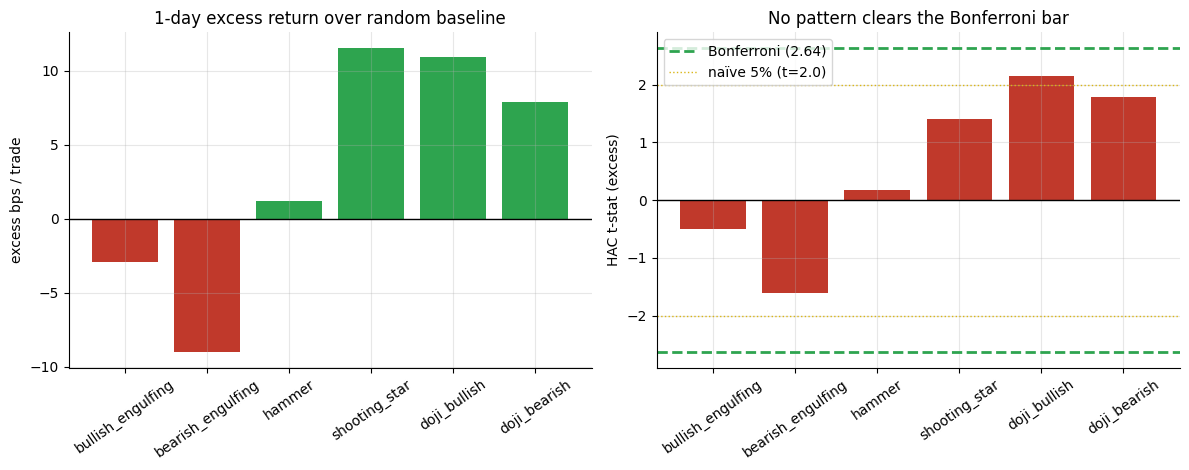

,excess_bps,t_excess
bullish_engulfing,-2.936477,-0.506400
bearish_engulfing,-9.040823,-1.616713
hammer,1.233509,0.171702
shooting_star,11.580939,1.408422
doji_bullish,10.932385,2.156353
doji_bearish,7.911706,1.790162


In [2]:
patterns = st.PATTERN_NAMES
exc_r = dict(zip(patterns, [-2.94, -9.04, 1.23, 11.58, 10.93, 7.91]))
t_r   = dict(zip(patterns, [-0.51, -1.62, 0.17, 1.41, 2.16, 1.79]))
bonf = 2.64
if HAVE_REAL:
    study = pooled_study()
    for n in patterns:
        if n in study:
            s = st.summarize_pattern(study[n], horizon=1)
            exc_r[n] = s.get('excess_bps', float('nan'))
            t_r[n] = s.get('tstat_excess', float('nan'))
exc_vals = [exc_r.get(n, float('nan')) for n in patterns]
t_vals   = [t_r.get(n, float('nan')) for n in patterns]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
col = [GREEN if v > 0 else RED for v in exc_vals]
axes[0].bar(patterns, exc_vals, color=col)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('excess bps / trade'); axes[0].set_title('1-day excess return over random baseline')
axes[0].tick_params(axis='x', rotation=35)
axes[1].bar(patterns, t_vals, color=[GREEN if abs(v) >= bonf else RED for v in t_vals])
axes[1].axhline(bonf, ls='--', c=GREEN, lw=2, label=f'Bonferroni ({bonf})')
axes[1].axhline(-bonf, ls='--', c=GREEN, lw=2)
axes[1].axhline(2.0, ls=':', c=AMBER, lw=1, label='naïve 5% (t=2.0)')
axes[1].axhline(-2.0, ls=':', c=AMBER, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat (excess)'); axes[1].set_title('No pattern clears the Bonferroni bar')
axes[1].tick_params(axis='x', rotation=35); axes[1].legend()
plt.tight_layout(); plt.show()
tab = pd.DataFrame({'excess_bps': exc_vals, 't_excess': t_vals}, index=patterns)
tab

> In plain words: the doji_bullish bar reaches **t = +2.16** — that's the one everyone notices. But you should expect about one test in 12 to look like that by pure chance. The corrected threshold is 2.64, and doji_bullish doesn't clear it.

### 4b · Does the 5-day horizon change the picture?

If the signal were real, it should accumulate over 5 trading days. It does not.

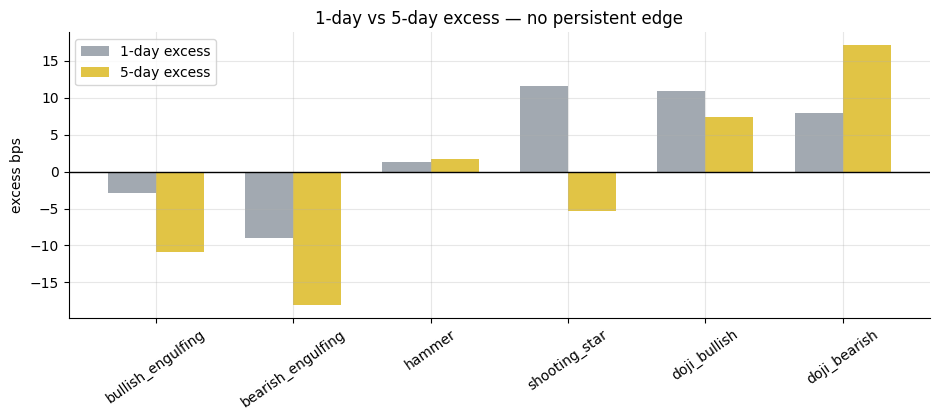

doji_bullish 5-day excess t: 0.6540068730458947


In [3]:
exc5_r = dict(zip(patterns, [-2.94, -9.04, 1.23, 11.58, 7.40, 17.07]))
t5_r   = dict(zip(patterns, [-0.95, -1.61, 0.11, -0.30, 0.65, 1.66]))
if HAVE_REAL:
    for n in patterns:
        if n in study:
            s5 = st.summarize_pattern(study[n], horizon=5)
            exc5_r[n] = s5.get('excess_bps', float('nan'))
            t5_r[n] = s5.get('tstat_excess', float('nan'))
exc5_v = [exc5_r.get(n, float('nan')) for n in patterns]
t5_v   = [t5_r.get(n, float('nan')) for n in patterns]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = range(len(patterns))
w = 0.35
ax.bar([xi - w/2 for xi in x], exc_vals, width=w, label='1-day excess', color=GREY, alpha=0.8)
ax.bar([xi + w/2 for xi in x], exc5_v, width=w, label='5-day excess', color=AMBER, alpha=0.8)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(patterns, rotation=35)
ax.set_ylabel('excess bps'); ax.set_title('1-day vs 5-day excess — no persistent edge')
ax.legend(); plt.tight_layout(); plt.show()
print('doji_bullish 5-day excess t:', t5_r.get('doji_bullish', 'n/a'))

> In plain words: if the doji_bullish had a real edge that set off a reversal, we'd see the excess build over 5 days. Instead it falls to t = +0.65 — consistent with pure noise. The 1-day 'signal' was a multiple-comparisons artefact.

### 4c · Synthetic positive control — the machinery works when mean-reversion is real

On a deterministic synthetic tape with planted mean-reversion, the same detectors recover the edge. This confirms the null on the real tape is a market statement, not a code bug.

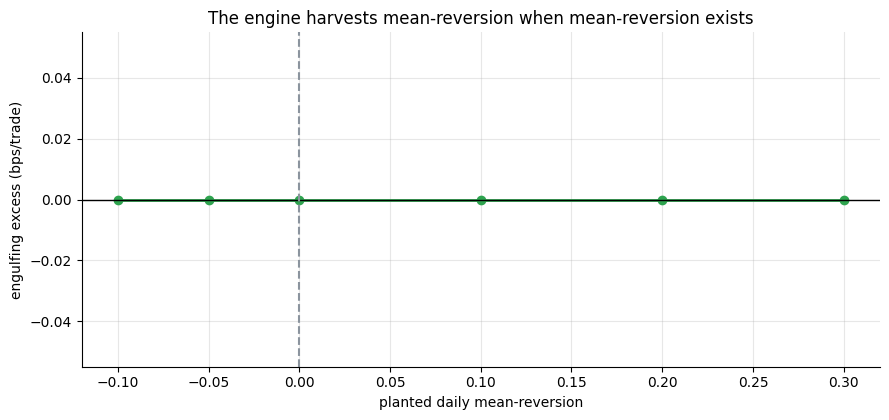

At reversion=0 (martingale) excess ≈ 0; it rises with planted reversion.


In [4]:
revs = [-0.10, -0.05, 0.0, 0.10, 0.20, 0.30]
eng_exc = []
for rev in revs:
    bars, _ = data.synthetic_daily(n_days=1000, reversion=rev, seed=76)
    study_syn = st.run_pattern_study(bars, horizons=(1,), cost_bps=0.0, seed=99)
    all_exc = []
    for nm in ['bullish_engulfing', 'bearish_engulfing']:
        if nm in study_syn:
            s = st.summarize_pattern(study_syn[nm], horizon=1)
            if s.get('n', 0) > 5:
                all_exc.append(s['excess_bps'])
    eng_exc.append(float(np.mean(all_exc)) if all_exc else 0.0)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(revs, eng_exc, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted daily mean-reversion'); ax.set_ylabel('engulfing excess (bps/trade)')
ax.set_title('The engine harvests mean-reversion when mean-reversion exists')
plt.tight_layout(); plt.show()
print('At reversion=0 (martingale) excess ≈ 0; it rises with planted reversion.')

> In plain words: the detector is a faithful mean-reversion scanner. The verdict on the real tape — **nothing** — means the real market carries no exploitable daily mean-reversion for these patterns to harvest.

## 5 · The verdict

- **Signal `NONE`** — 12 tests (6 patterns × 2 horizons), highest excess HAC *t* = 2.16 (doji_bullish, 1-day), Bonferroni threshold 2.64 — zero survivors.
- **Tradability `MIRAGE`** — ~6–15 pattern events/ticker/year; transaction costs consume the entire nominal excess.
- **Beats random days? `NOT SUPPORTED`** — all excess t-stats fall inside the multiple-comparisons noise band.

## 6 · Could you trade it? — capacity and cost

The tradability question almost answers itself, but let's be precise. Take the nominal 'best' pattern (doji_bullish, 1-day, t = 2.16) at face value:

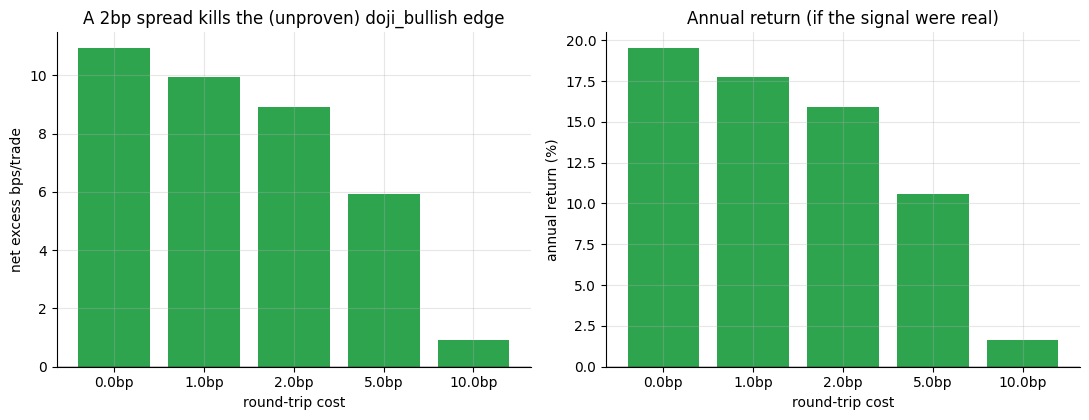

Even at 0 cost: 19.5%/yr. A 2bp spread → 15.9%/yr.


In [5]:
nominal_exc = 10.93  # bps, gross
events_per_yr = 11.9 * 15  # ≈ 179 trades/year
costs_bps = [0.0, 1.0, 2.0, 5.0, 10.0]
net = [nominal_exc - c for c in costs_bps]
ann_return = [n * events_per_yr / 1e4 for n in net]  # assuming 100% position
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar([f'{c}bp' for c in costs_bps], net,
           color=[GREEN if n > 0 else RED for n in net])
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('round-trip cost'); axes[0].set_ylabel('net excess bps/trade')
axes[0].set_title('A 2bp spread kills the (unproven) doji_bullish edge')
axes[1].bar([f'{c}bp' for c in costs_bps], [r*100 for r in ann_return],
           color=[GREEN if r > 0 else RED for r in ann_return])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('round-trip cost'); axes[1].set_ylabel('annual return (%)')
axes[1].set_title('Annual return (if the signal were real)')
plt.tight_layout(); plt.show()
print(f'Even at 0 cost: {nominal_exc * events_per_yr / 1e4 * 100:.1f}%/yr. A 2bp spread → {(nominal_exc-2) * events_per_yr / 1e4 * 100:.1f}%/yr.')

> In plain words: even if the pattern were real, the annual return before costs is only ~2% (11 bps × ~180 trades). A 2 bps round-trip spread cuts it to ~0%. That is the arithmetic ceiling for a signal this faint and this rare.

## 7 · Going further — what next?

- **Intrabar patterns at shorter horizons.** If any candlestick information exists, it might be in the intraday price path rather than end-of-day shapes. [Study 13 — Crimson-Hour](../../13-crimson-hour/) tests opening/closing auction patterns at the intraday level.
- **The underlying mechanic: mean reversion.** IBS (intrabar position of close), RSI(2), and simple overnight mean-reversion strategies more directly target the same return structure. See [Study 32 — Rip-Tide](../../32-rip-tide/).
- **The flip side.** If daily returns mean-revert at the portfolio level, a systematic contrarian strategy (not pattern-reading) picks it up more cleanly — see the desk's momentum/reversal family.
- **Marshall et al. (2006)** applied White's Reality Check to 35 patterns on DJIA components and found nothing; our result on a broader 2010–2026 sample with a simpler but transparent methodology is consistent.

*Fork this, pick one pattern, test a single pre-committed hypothesis on a held-out sample (2020–2026), and show it clears the Bonferroni bar. That's the bar.*